# Versão 3 - Treino e Validação


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
CANDIDATE_DIRS = [
    CURRENT_DIR,
    CURRENT_DIR / "versao3",
    CURRENT_DIR.parent / "versao3",
]
NOTEBOOK_DIR = next((candidate for candidate in CANDIDATE_DIRS if (candidate / "pipeline_v3.py").exists()), CURRENT_DIR)
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from copy import deepcopy
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from pipeline_v3 import (
    GroupedWindowDataset,
    HybridResidualForecaster,
    load_bundle,
    load_grouped_sequences_from_directory,
    run_epoch,
    set_seed,
)

set_seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [2]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2", "versao3"} else CURRENT_DIR
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PREPROCESSED_V3_DIR = ARTIFACTS_DIR / "preprocessed_v3"
BUNDLE_PATH = PREPROCESSED_V3_DIR / "preprocessing_bundle_v3.json"
MODELS_DIR = ARTIFACTS_DIR / "models"
MODEL_PATH = MODELS_DIR / "hybrid_residual_forecaster_v3.pt"
MODEL_CONFIG_PATH = MODELS_DIR / "hybrid_residual_forecaster_v3_config.json"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

bundle = load_bundle(BUNDLE_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pd.DataFrame(
    {
        "aspecto": ["device", "input_features", "target_features", "well_count"],
        "valor": [str(device), len(bundle.input_columns), len(bundle.target_columns), len(bundle.well_to_id)],
    }
)


,aspecto,valor
0,device,cuda
1,input_features,36
2,target_features,6
3,well_count,42


In [3]:
train_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V3_DIR / "train",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)
validation_groups = load_grouped_sequences_from_directory(
    PREPROCESSED_V3_DIR / "validation",
    input_columns=bundle.input_columns,
    target_columns=bundle.target_columns,
)

SEQUENCE_LENGTH = bundle.sequence_length_recommendation
TRAIN_BATCH_SIZE = 128
VALIDATION_BATCH_SIZE = 256
TRAIN_SAMPLED_WINDOWS = 120_000
VALIDATION_SAMPLED_WINDOWS = 40_000

train_dataset = GroupedWindowDataset(
    groups=train_groups,
    sequence_length=SEQUENCE_LENGTH,
    sampled_windows=TRAIN_SAMPLED_WINDOWS,
    seed=42,
)
validation_dataset = GroupedWindowDataset(
    groups=validation_groups,
    sequence_length=SEQUENCE_LENGTH,
    sampled_windows=VALIDATION_SAMPLED_WINDOWS,
    seed=123,
)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False, num_workers=0)

window_overview_df = pd.DataFrame(
    [
        {
            "split": "train",
            "series": len(train_groups),
            "janelas_ativas": len(train_dataset),
            "janelas_totais": len(train_dataset._full_index),
        },
        {
            "split": "validation",
            "series": len(validation_groups),
            "janelas_ativas": len(validation_dataset),
            "janelas_totais": len(validation_dataset._full_index),
        },
    ]
)
window_overview_df


,split,series,janelas_ativas,janelas_totais
0,train,1554,120000,54427623
1,validation,314,40000,9642628


In [4]:
batch_example = next(iter(train_loader))
{
    "x_shape": tuple(batch_example["x"].shape),
    "y_shape": tuple(batch_example["y"].shape),
    "well_id_shape": tuple(batch_example["well_id"].shape),
}


{'x_shape': (128, 60, 36), 'y_shape': (128, 6), 'well_id_shape': (128,)}

In [5]:
RAW_TARGET_POSITIONS = [bundle.input_columns.index(column_name) for column_name in bundle.raw_target_input_columns]

MODEL_DIM = 128
GRU_HIDDEN_SIZE = 128
GRU_LAYERS = 2
WELL_EMBEDDING_DIM = 16
DROPOUT = 0.20

model = HybridResidualForecaster(
    input_size=len(bundle.input_columns),
    target_size=len(bundle.target_columns),
    well_count=max(len(bundle.well_to_id), 1),
    raw_target_positions=RAW_TARGET_POSITIONS,
    model_dim=MODEL_DIM,
    gru_hidden_size=GRU_HIDDEN_SIZE,
    gru_layers=GRU_LAYERS,
    well_embedding_dim=WELL_EMBEDDING_DIM,
    dropout=DROPOUT,
).to(device)

params_df = pd.DataFrame(
    {
        "aspecto": ["parametros_treinaveis"],
        "valor": [sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)],
    }
)
params_df


,aspecto,valor
0,parametros_treinaveis,894031


In [6]:
MAX_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

history_rows = []
best_state_dict = None
best_epoch = None
best_score = np.inf
best_val_mae = np.inf
best_val_persistence_mae = np.inf
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_dataset.resample(epoch)
    validation_dataset.resample(epoch)

    train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        raw_target_positions=RAW_TARGET_POSITIONS,
    )
    validation_metrics = run_epoch(
        model=model,
        loader=validation_loader,
        optimizer=None,
        device=device,
        raw_target_positions=RAW_TARGET_POSITIONS,
    )

    scheduler.step(validation_metrics["model_mae"])
    current_score = validation_metrics["model_mae"] / max(validation_metrics["persistence_mae"], 1e-8)

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_mae": train_metrics["model_mae"],
            "val_loss": validation_metrics["loss"],
            "val_mae": validation_metrics["model_mae"],
            "val_persistence_mae": validation_metrics["persistence_mae"],
            "val_mae_ratio_to_persistence": current_score,
            "val_improvement_pct": validation_metrics["mae_improvement_pct"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.5f} | "
        f"val_loss={validation_metrics['loss']:.5f} | "
        f"val_mae={validation_metrics['model_mae']:.5f} | "
        f"persist_mae={validation_metrics['persistence_mae']:.5f} | "
        f"ratio={current_score:.4f} | "
        f"improvement={validation_metrics['mae_improvement_pct']:.2f}%"
    )

    if current_score < best_score:
        best_score = current_score
        best_epoch = epoch
        best_val_mae = validation_metrics["model_mae"]
        best_val_persistence_mae = validation_metrics["persistence_mae"]
        best_state_dict = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        break

history_df = pd.DataFrame(history_rows)
if best_state_dict is None:
    raise RuntimeError("Nenhum checkpoint foi salvo durante o treino.")

model.load_state_dict(best_state_dict)
history_df


Epoch 01 | train_loss=0.00005 | val_loss=0.00000 | val_mae=0.00039 | persist_mae=0.00012 | ratio=3.1612 | improvement=-216.12%
Epoch 02 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00023 | persist_mae=0.00012 | ratio=1.8195 | improvement=-81.95%
Epoch 03 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00021 | persist_mae=0.00013 | ratio=1.6356 | improvement=-63.56%
Epoch 04 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00022 | persist_mae=0.00012 | ratio=1.7878 | improvement=-78.78%
Epoch 05 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00021 | persist_mae=0.00013 | ratio=1.6708 | improvement=-67.08%
Epoch 06 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00019 | persist_mae=0.00012 | ratio=1.5640 | improvement=-56.40%
Epoch 07 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00016 | persist_mae=0.00013 | ratio=1.2851 | improvement=-28.51%
Epoch 08 | train_loss=0.00000 | val_loss=0.00000 | val_mae=0.00020 | persist_mae=0.00013 | ratio=1.5689 | improvement

,epoch,train_loss,train_mae,val_loss,val_mae,val_persistence_mae,val_mae_ratio_to_persistence,val_improvement_pct,learning_rate
0,1,4.845379e-05,0.005497,6.220026e-07,0.000394,0.000125,3.161229,-216.122860,0.00030
1,2,4.976070e-06,0.001957,5.537204e-07,0.000226,0.000124,1.819496,-81.949616,0.00030
2,3,2.034187e-06,0.001113,4.023886e-07,0.000206,0.000126,1.635590,-63.558967,0.00030
3,4,1.376337e-06,0.000742,3.467662e-07,0.000220,0.000123,1.787822,-78.782171,0.00030
4,5,9.940130e-07,0.000572,3.695633e-07,0.000209,0.000125,1.670763,-67.076260,0.00030
5,6,8.606075e-07,0.000477,4.450983e-07,0.000194,0.000124,1.563950,-56.395035,0.00030
6,7,7.992553e-07,0.000412,3.917761e-07,0.000163,0.000127,1.285123,-28.512272,0.00030
7,8,7.051528e-07,0.000359,3.526211e-07,0.000199,0.000127,1.568927,-56.892653,0.00030
8,9,6.867588e-07,0.000317,2.556805e-07,0.000173,0.000124,1.398509,-39.850884,0.00030
9,10,6.990616e-07,0.000293,2.527299e-07,0.000140,0.000124,1.130713,-13.071305,0.00030


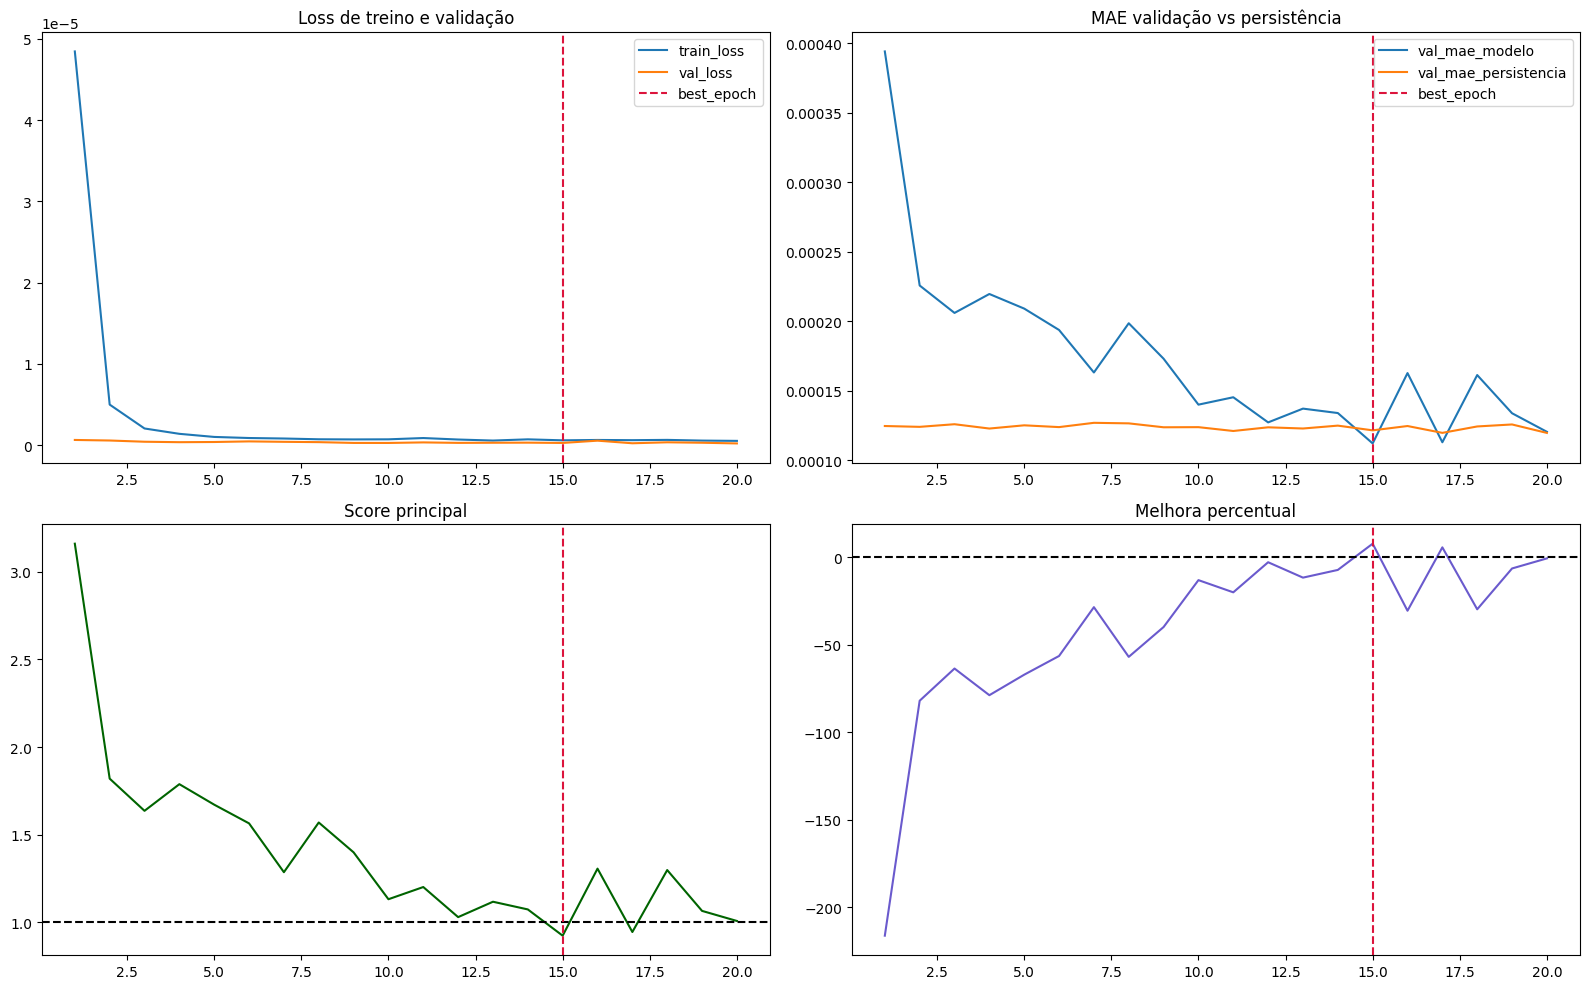

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0, 0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0, 0].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[0, 0].set_title("Loss de treino e validação")
axes[0, 0].legend()

axes[0, 1].plot(history_df["epoch"], history_df["val_mae"], label="val_mae_modelo")
axes[0, 1].plot(history_df["epoch"], history_df["val_persistence_mae"], label="val_mae_persistencia")
axes[0, 1].axvline(best_epoch, color="crimson", linestyle="--", label="best_epoch")
axes[0, 1].set_title("MAE validação vs persistência")
axes[0, 1].legend()

axes[1, 0].plot(history_df["epoch"], history_df["val_mae_ratio_to_persistence"], color="darkgreen")
axes[1, 0].axhline(1.0, color="black", linestyle="--")
axes[1, 0].axvline(best_epoch, color="crimson", linestyle="--")
axes[1, 0].set_title("Score principal")

axes[1, 1].plot(history_df["epoch"], history_df["val_improvement_pct"], color="slateblue")
axes[1, 1].axhline(0.0, color="black", linestyle="--")
axes[1, 1].axvline(best_epoch, color="crimson", linestyle="--")
axes[1, 1].set_title("Melhora percentual")

plt.tight_layout()
plt.show()


In [8]:
training_summary_df = pd.DataFrame(
    {
        "aspecto": [
            "best_epoch",
            "best_val_mae",
            "best_val_persistence_mae",
            "best_ratio_to_persistence",
            "epochs_executed",
        ],
        "valor": [
            best_epoch,
            best_val_mae,
            best_val_persistence_mae,
            best_score,
            len(history_df),
        ],
    }
)
training_summary_df


,aspecto,valor
0,best_epoch,15.000000
1,best_val_mae,0.000112
2,best_val_persistence_mae,0.000122
3,best_ratio_to_persistence,0.922577
4,epochs_executed,20.000000


In [9]:
torch.save(model.state_dict(), MODEL_PATH)

model_config = {
    "model_name": "hybrid_residual_forecaster_v3",
    "sequence_length": SEQUENCE_LENGTH,
    "input_size": len(bundle.input_columns),
    "target_size": len(bundle.target_columns),
    "raw_target_positions": RAW_TARGET_POSITIONS,
    "model_dim": MODEL_DIM,
    "gru_hidden_size": GRU_HIDDEN_SIZE,
    "gru_layers": GRU_LAYERS,
    "well_embedding_dim": WELL_EMBEDDING_DIM,
    "dropout": DROPOUT,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "validation_batch_size": VALIDATION_BATCH_SIZE,
    "train_sampled_windows": TRAIN_SAMPLED_WINDOWS,
    "validation_sampled_windows": VALIDATION_SAMPLED_WINDOWS,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": int(best_epoch),
    "best_val_mae": float(best_val_mae),
    "best_val_persistence_mae": float(best_val_persistence_mae),
    "best_ratio_to_persistence": float(best_score),
    "executed_epochs": int(len(history_df)),
    "bundle_path": str(BUNDLE_PATH),
    "model_path": str(MODEL_PATH),
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, ensure_ascii=False, indent=2))
model_config


{'model_name': 'hybrid_residual_forecaster_v3',
 'sequence_length': 60,
 'input_size': 36,
 'target_size': 6,
 'raw_target_positions': [0, 1, 2, 3, 4, 5],
 'model_dim': 128,
 'gru_hidden_size': 128,
 'gru_layers': 2,
 'well_embedding_dim': 16,
 'dropout': 0.2,
 'train_batch_size': 128,
 'validation_batch_size': 256,
 'train_sampled_windows': 120000,
 'validation_sampled_windows': 40000,
 'max_epochs': 20,
 'patience': 5,
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'best_epoch': 15,
 'best_val_mae': 0.00011215054109925404,
 'best_val_persistence_mae': 0.00012156220327597111,
 'best_ratio_to_persistence': 0.9225773972247716,
 'executed_epochs': 20,
 'bundle_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/preprocessed_v3/preprocessing_bundle_v3.json',
 'model_path': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/models/hybrid_residual_forecaster_v3.pt'}